[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/next-gen-aiam/blob/rl/foundation/notebooks/04f_rl_n29_training.ipynb)

# Notebook 04f — RL N=29 Walk-Forward Training (Session 4c)

REINFORCE+baseline on the full 29-asset universe with monthly walk-forward refit.  
Two configs: λ_risk = 0.02 (baseline) vs λ_risk = 0.00 (no risk penalty).  
Key question: does full-rollout training at N=29 produce feature-conditional policies, or does
the static collapse observed in Session 4b at N=1/2/3 with 60-step truncation persist at scale?

In [1]:
!nvidia-smi

Wed May 20 11:59:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             49W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys, os, time, warnings
from pathlib import Path

IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print('Detected Colab — cloning repo...')
    os.system('git clone -b rl/foundation https://github.com/FranQuant/next-gen-aiam.git 2>&1 | tail -3')
    os.chdir('next-gen-aiam')
    print(f'Working dir: {os.getcwd()}')
    print('Installing dependencies...')
    os.system('pip install -q -e . 2>&1 | tail -3')
    os.system('pip install -q pyarrow scipy scikit-learn cvxpy pandas matplotlib seaborn torch 2>&1 | tail -3')
else:
    print(f'Detected local environment — {os.getcwd()}')

import torch

if torch.cuda.is_available():
    DEVICE = 'cuda'
    GPU_NAME = torch.cuda.get_device_name(0)
    if IS_COLAB:
        os.system('nvidia-smi')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    GPU_NAME = 'Apple Silicon MPS'
else:
    DEVICE = 'cpu'
    GPU_NAME = 'CPU'

print(f'Device : {DEVICE}  ({GPU_NAME})')
print(f'torch  : {torch.__version__}')

# Run mode: full on Colab GPU, smoke on local CPU
if DEVICE == 'cuda':
    SEEDS     = list(range(10))
    EPISODES  = 200
    MAX_STEPS = None    # full rollouts (~500 steps per training episode)
    RUN_MODE  = 'full'
else:
    SEEDS     = [0]
    EPISODES  = 5
    MAX_STEPS = 30      # truncated for fast local smoke test
    RUN_MODE  = 'smoke'

print(f'Run mode : {RUN_MODE}')
print(f'Seeds    : {SEEDS}')
print(f'Episodes : {EPISODES}')
print(f'Max steps: {MAX_STEPS}')

Detected Colab — cloning repo...
Working dir: /content/next-gen-aiam
Installing dependencies...
Device : cuda  (NVIDIA RTX PRO 6000 Blackwell Server Edition)
torch  : 2.10.0+cu128
Run mode : full
Seeds    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Episodes : 200
Max steps: None


## §1 Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})
warnings.filterwarnings('ignore')

ROOT = Path(os.getcwd())
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent

for p in [str(ROOT / 'src'), str(ROOT / 'notebooks')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from _shared import ann_sharpe, ann_return, ann_vol, max_drawdown, TRADING_DAYS
from aiam.data.split import TEST_START, TRAIN_END
from aiam.dl.walkforward import generate_refit_dates
from aiam.rl.env import PortfolioEnv
from aiam.rl.policy import SimplexPolicy
from aiam.rl.trainer import TrainConfig
from aiam.rl.walkforward import WalkForwardRLEnsemble, fit_walkforward_rl

RESULTS_DIR = ROOT / 'results' / 'rl' / 'n29'
FIG_DIR     = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

COST_BPS   = 10.0
LOOKBACK   = 20    # feature dimension = rolling 20-day return windows per asset
HIDDEN_DIM = 32
TRAIN_WINDOW_MONTHS = 24

print(f'ROOT       : {ROOT}')
print(f'Results dir: {RESULTS_DIR}')
print(f'TEST_START : {TEST_START}   TRAIN_END: {TRAIN_END}')

ROOT       : /content/next-gen-aiam
Results dir: /content/next-gen-aiam/results/rl/n29
TEST_START : 2023-01-01 00:00:00   TRAIN_END: 2022-12-31 00:00:00


## §2 Data Loading — 29-Asset Returns

In [4]:
# Compute daily returns from prices
prices = pd.read_parquet(ROOT / 'data' / 'cache' / 'prices_29.parquet')
returns_all = prices.pct_change().dropna()

# Split
returns_train = returns_all.loc[:TRAIN_END]
returns_oos   = returns_all.loc[TEST_START:]
ASSETS = returns_all.columns.tolist()
N_ASSETS = len(ASSETS)

print(f'Universe   : {N_ASSETS} assets')
print(f'Full period: {returns_all.index[0].date()} → {returns_all.index[-1].date()}  ({len(returns_all)} days)')
print(f'Train      : {returns_train.index[0].date()} → {returns_train.index[-1].date()}  ({len(returns_train)} days)')
print(f'OOS        : {returns_oos.index[0].date()} → {returns_oos.index[-1].date()}   ({len(returns_oos)} days)')
print(f'\nAssets: {ASSETS}')

Universe   : 29 assets
Full period: 2007-04-12 → 2026-04-30  (4794 days)
Train      : 2007-04-12 → 2022-12-30  (3960 days)
OOS        : 2023-01-03 → 2026-04-30   (834 days)

Assets: ['AAPL.US', 'MSFT.US', 'GOOGL.US', 'NVDA.US', 'JPM.US', 'JNJ.US', 'XOM.US', 'WMT.US', 'XLK.US', 'XLF.US', 'XLE.US', 'XLV.US', 'XLP.US', 'XLU.US', 'SPY.US', 'IWM.US', 'EFA.US', 'EEM.US', 'FXI.US', 'SHY.US', 'IEF.US', 'TLT.US', 'AGG.US', 'HYG.US', 'GLD.US', 'SLV.US', 'DBC.US', 'USO.US', 'EURUSD.FOREX']


## §3 Walk-Forward Setup

In [5]:
oos_start = pd.Timestamp(TEST_START)
oos_end   = returns_all.index[-1]

refit_dates = generate_refit_dates(
    test_start=oos_start,
    test_end=oos_end,
    cadence='monthly',
    calendar=returns_all.index,
)

print(f'Refit dates: {len(refit_dates)}')
print(f'First refit: {refit_dates[0].date()}')
print(f'Last refit : {refit_dates[-1].date()}')
print()

# Show training windows for first 3 refits
for rd in refit_dates[:3]:
    train_end   = rd - pd.Timedelta(days=1)
    train_start = rd - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)
    window_returns = returns_all.loc[
        (returns_all.index >= train_start) & (returns_all.index <= train_end)
    ]
    print(f'  Refit {rd.date()}: train {train_start.date()} → {train_end.date()} ({len(window_returns)} days)')

total_fits = 2 * len(SEEDS) * len(refit_dates)
print(f'\nTotal policy fits: 2 configs × {len(SEEDS)} seeds × {len(refit_dates)} refits = {total_fits}')

Refit dates: 41
First refit: 2022-12-01
Last refit : 2026-04-01

  Refit 2022-12-01: train 2020-12-01 → 2022-11-30 (504 days)
  Refit 2023-01-03: train 2021-01-03 → 2023-01-02 (503 days)
  Refit 2023-02-01: train 2021-02-01 → 2023-01-31 (504 days)

Total policy fits: 2 configs × 10 seeds × 41 refits = 820


## §4 Training — Config A  (λ_risk = 0.02, Session 4b baseline)

In [6]:
LAMBDA_A = 0.02

config_A = TrainConfig(
    episodes=EPISODES,
    gamma=0.95,
    lr=1e-3,
    entropy_coef=0.01,
    grad_clip=1.0,
    seed=0,
    max_steps_per_episode=MAX_STEPS,
)

print(f'Config A: lambda_risk={LAMBDA_A}, episodes={EPISODES}, max_steps={MAX_STEPS}')
t0 = time.time()

wf_A = fit_walkforward_rl(
    returns=returns_all,
    refit_dates=refit_dates,
    config=config_A,
    seeds=SEEDS,
    hidden_dim=HIDDEN_DIM,
    training_window_months=TRAIN_WINDOW_MONTHS,
    lambda_risk=LAMBDA_A,
    verbose=True,
)

elapsed_A = time.time() - t0
print(f'\nConfig A done in {elapsed_A:.1f}s ({elapsed_A/60:.1f} min)')

Config A: lambda_risk=0.02, episodes=200, max_steps=None
  Refit  1/41: 2020-12-01 → 2022-11-30 (504 days) | seeds=10 | final_reward=-0.74353 | mean_to=1.8652 | 307.8s
  Refit  2/41: 2021-01-03 → 2023-01-02 (503 days) | seeds=10 | final_reward=-0.97317 | mean_to=1.8682 | 305.6s
  Refit  3/41: 2021-02-01 → 2023-01-31 (504 days) | seeds=10 | final_reward=-0.91783 | mean_to=1.8666 | 305.9s
  Refit  4/41: 2021-03-01 → 2023-02-28 (504 days) | seeds=10 | final_reward=-0.91478 | mean_to=1.8676 | 305.7s
  Refit  5/41: 2021-04-03 → 2023-04-02 (503 days) | seeds=10 | final_reward=-0.85067 | mean_to=1.8664 | 304.8s
  Refit  6/41: 2021-05-01 → 2023-04-30 (502 days) | seeds=10 | final_reward=-0.88132 | mean_to=1.8682 | 302.8s
  Refit  7/41: 2021-06-01 → 2023-05-31 (504 days) | seeds=10 | final_reward=-0.93980 | mean_to=1.8676 | 307.7s
  Refit  8/41: 2021-07-03 → 2023-07-02 (501 days) | seeds=10 | final_reward=-0.99201 | mean_to=1.8678 | 305.4s
  Refit  9/41: 2021-08-01 → 2023-07-31 (502 days) | see

## §5 Training — Config B  (λ_risk = 0.00, no risk penalty)

In [7]:
LAMBDA_B = 0.00

config_B = TrainConfig(
    episodes=EPISODES,
    gamma=0.95,
    lr=1e-3,
    entropy_coef=0.01,
    grad_clip=1.0,
    seed=0,
    max_steps_per_episode=MAX_STEPS,
)

print(f'Config B: lambda_risk={LAMBDA_B}, episodes={EPISODES}, max_steps={MAX_STEPS}')
t0 = time.time()

wf_B = fit_walkforward_rl(
    returns=returns_all,
    refit_dates=refit_dates,
    config=config_B,
    seeds=SEEDS,
    hidden_dim=HIDDEN_DIM,
    training_window_months=TRAIN_WINDOW_MONTHS,
    lambda_risk=LAMBDA_B,
    verbose=True,
)

elapsed_B = time.time() - t0
print(f'\nConfig B done in {elapsed_B:.1f}s ({elapsed_B/60:.1f} min)')

Config B: lambda_risk=0.0, episodes=200, max_steps=None
  Refit  1/41: 2020-12-01 → 2022-11-30 (504 days) | seeds=10 | final_reward=-0.68519 | mean_to=1.8666 | 332.2s
  Refit  2/41: 2021-01-03 → 2023-01-02 (503 days) | seeds=10 | final_reward=-0.82826 | mean_to=1.8693 | 329.0s
  Refit  3/41: 2021-02-01 → 2023-01-31 (504 days) | seeds=10 | final_reward=-0.71399 | mean_to=1.8677 | 332.1s
  Refit  4/41: 2021-03-01 → 2023-02-28 (504 days) | seeds=10 | final_reward=-0.73700 | mean_to=1.8703 | 335.1s
  Refit  5/41: 2021-04-03 → 2023-04-02 (503 days) | seeds=10 | final_reward=-0.73960 | mean_to=1.8661 | 332.0s
  Refit  6/41: 2021-05-01 → 2023-04-30 (502 days) | seeds=10 | final_reward=-0.68261 | mean_to=1.8662 | 330.2s
  Refit  7/41: 2021-06-01 → 2023-05-31 (504 days) | seeds=10 | final_reward=-0.87355 | mean_to=1.8671 | 333.1s
  Refit  8/41: 2021-07-03 → 2023-07-02 (501 days) | seeds=10 | final_reward=-0.88573 | mean_to=1.8664 | 331.4s
  Refit  9/41: 2021-08-01 → 2023-07-31 (502 days) | seed

## §6 OOS Evaluation

In [8]:
print('Evaluating Config A OOS...')
ret_A, weights_A, diag_A = wf_A.evaluate_oos(
    returns_all, oos_start=oos_start, oos_end=oos_end, lookback=LOOKBACK
)

print('Evaluating Config B OOS...')
ret_B, weights_B, diag_B = wf_B.evaluate_oos(
    returns_all, oos_start=oos_start, oos_end=oos_end, lookback=LOOKBACK
)

sharpe_A = ann_sharpe(ret_A)
sharpe_B = ann_sharpe(ret_B)

print(f'\nConfig A (λ=0.02): Sharpe={sharpe_A:.4f}  AnnRet={ann_return(ret_A):.4f}  AnnVol={ann_vol(ret_A):.4f}  MaxDD={max_drawdown(ret_A):.4f}')
print(f'Config B (λ=0.00): Sharpe={sharpe_B:.4f}  AnnRet={ann_return(ret_B):.4f}  AnnVol={ann_vol(ret_B):.4f}  MaxDD={max_drawdown(ret_B):.4f}')
print(f'\nML bar (MSR Ensemble): 2.579')
print(f'Gap A vs ML bar: {sharpe_A - 2.579:.3f}')
print(f'Gap B vs ML bar: {sharpe_B - 2.579:.3f}')

Evaluating Config A OOS...
Evaluating Config B OOS...

Config A (λ=0.02): Sharpe=2.0255  AnnRet=0.2205  AnnVol=0.1009  MaxDD=-0.1216
Config B (λ=0.00): Sharpe=2.0256  AnnRet=0.2205  AnnVol=0.1009  MaxDD=-0.1216

ML bar (MSR Ensemble): 2.579
Gap A vs ML bar: -0.554
Gap B vs ML bar: -0.553


## §7 Static Collapse Gate

**GATE**: if `mean_turnover < 0.05` AND `mean_weight_std_across_time < 0.01` for BOTH configs,
the static collapse has reproduced at N=29 with full rollouts.

In [9]:
TO_THRESH   = 0.05   # turnover threshold
WSTD_THRESH = 0.01   # weight std-across-time threshold

mean_to_A   = diag_A['mean_turnover']
wstd_A      = diag_A['weight_std_across_time']
mean_to_B   = diag_B['mean_turnover']
wstd_B      = diag_B['weight_std_across_time']

# Also compute within-refit training turnover from histories
train_to_A = np.mean([
    np.mean(h.mean_turnovers[-10:]) if h.mean_turnovers else 0.0
    for rr in wf_A.refit_results for h in rr.histories
])
train_to_B = np.mean([
    np.mean(h.mean_turnovers[-10:]) if h.mean_turnovers else 0.0
    for rr in wf_B.refit_results for h in rr.histories
])

collapsed_A = (mean_to_A < TO_THRESH) and (wstd_A < WSTD_THRESH)
collapsed_B = (mean_to_B < TO_THRESH) and (wstd_B < WSTD_THRESH)

print('=' * 60)
print('FEATURE-CONDITIONAL CHECK')
print('=' * 60)
print(f'Config A (λ=0.02)')
print(f'  OOS mean_turnover             : {mean_to_A:.5f}  (thresh {TO_THRESH})')
print(f'  OOS weight_std_across_time    : {wstd_A:.5f}  (thresh {WSTD_THRESH})')
print(f'  Training mean_turnover (last10): {train_to_A:.5f}')
print(f'  Static collapse?               : {collapsed_A}')
print()
print(f'Config B (λ=0.00)')
print(f'  OOS mean_turnover             : {mean_to_B:.5f}  (thresh {TO_THRESH})')
print(f'  OOS weight_std_across_time    : {wstd_B:.5f}  (thresh {WSTD_THRESH})')
print(f'  Training mean_turnover (last10): {train_to_B:.5f}')
print(f'  Static collapse?               : {collapsed_B}')
print()

if collapsed_A and collapsed_B:
    verdict = 'STATIC_COLLAPSE_DETECTED'
    print('*** STATIC_COLLAPSE_DETECTED ***')
    print('Both configs collapsed to static policies at N=29 with full rollouts.')
    print('This IS the finding. Proceeding to comparison table and findings doc.')
elif collapsed_A or collapsed_B:
    verdict = 'PARTIAL_COLLAPSE'
    which = 'Config A' if collapsed_A else 'Config B'
    print(f'*** PARTIAL_COLLAPSE ({which} collapsed, other did not) ***')
else:
    verdict = 'FEATURE_CONDITIONAL_LEARNING'
    print('*** FEATURE_CONDITIONAL_LEARNING ***')
    print('At least one config shows non-trivial turnover and weight variation.')
    print('Full rollouts at N=29 enabled feature-conditional learning.')

print(f'\nVERDICT: {verdict}')

FEATURE-CONDITIONAL CHECK
Config A (λ=0.02)
  OOS mean_turnover             : 0.00068  (thresh 0.05)
  OOS weight_std_across_time    : 0.00003  (thresh 0.01)
  Training mean_turnover (last10): 1.86732
  Static collapse?               : True

Config B (λ=0.00)
  OOS mean_turnover             : 0.00077  (thresh 0.05)
  OOS weight_std_across_time    : 0.00003  (thresh 0.01)
  Training mean_turnover (last10): 1.86736
  Static collapse?               : True

*** STATIC_COLLAPSE_DETECTED ***
Both configs collapsed to static policies at N=29 with full rollouts.
This IS the finding. Proceeding to comparison table and findings doc.

VERDICT: STATIC_COLLAPSE_DETECTED


## §8 Training Diagnostics

In [10]:
# Build per-refit-per-seed diagnostics
diag_rows = []
for config_name, wf_ensemble, lambda_val in [
    ('config_A', wf_A, LAMBDA_A),
    ('config_B', wf_B, LAMBDA_B),
]:
    for rr in wf_ensemble.refit_results:
        for seed_idx, (agent, hist) in enumerate(zip(rr.agents, rr.histories)):
            seed = SEEDS[seed_idx]
            final_reward = hist.episode_rewards[-1] if hist.episode_rewards else float('nan')
            mean_to_train = float(np.mean(hist.mean_turnovers)) if hist.mean_turnovers else float('nan')
            last10_to     = float(np.mean(hist.mean_turnovers[-10:])) if hist.mean_turnovers else float('nan')
            mean_w = hist.mean_weights[-1] if hist.mean_weights else np.full(N_ASSETS, float('nan'))
            w_std  = float(np.std(mean_w)) if not np.all(np.isnan(mean_w)) else float('nan')
            diag_rows.append({
                'config': config_name,
                'lambda_risk': lambda_val,
                'refit_date': rr.refit_date,
                'seed': seed,
                'final_episode_reward': final_reward,
                'mean_turnover_training': mean_to_train,
                'last10ep_turnover': last10_to,
                'final_weight_std': w_std,
            })

diag_df = pd.DataFrame(diag_rows)
diag_path = RESULTS_DIR / 'diagnostics_all.parquet'
diag_df.to_parquet(diag_path)
print(f'Saved diagnostics → {diag_path}')
print(diag_df.groupby('config')[['mean_turnover_training','last10ep_turnover','final_weight_std']].mean().round(5).to_string())

Saved diagnostics → /content/next-gen-aiam/results/rl/n29/diagnostics_all.parquet
          mean_turnover_training  last10ep_turnover  final_weight_std
config                                                               
config_A                 1.86787            1.86732           0.00567
config_B                 1.86790            1.86736           0.00564


## §9 Comparison vs 37-Strategy Table

In [11]:
base_csv = ROOT / 'data' / 'cache' / 'portfolio_returns' / 'dl_strategies_extended_comparison.csv'
base_df  = pd.read_csv(base_csv, index_col=0)
print(f'Base comparison: {len(base_df)} strategies')

# EW benchmark from base returns for turnover/tc stats
def _rl_row(ret_series: pd.Series, config_label: str, family: str) -> dict:
    return {
        'Ann Ret' : ann_return(ret_series),
        'Ann Vol' : ann_vol(ret_series),
        'Sharpe'  : ann_sharpe(ret_series),
        'Max DD'  : max_drawdown(ret_series),
        'Family'  : family,
    }

rl_rows = pd.DataFrame([
    _rl_row(ret_A, 'RL_lambda_002_ensemble', 'RL (REINFORCE, λ=0.02)'),
    _rl_row(ret_B, 'RL_lambda_000_ensemble', 'RL (REINFORCE, λ=0.00)'),
], index=['RL_lambda_002_ensemble', 'RL_lambda_000_ensemble'])

full_df = pd.concat([base_df, rl_rows])
full_df = full_df.sort_values('Sharpe', ascending=False)

out_csv = ROOT / 'data' / 'cache' / 'portfolio_returns' / 'full_comparison_with_rl.csv'
full_df.to_csv(out_csv)
print(f'Full comparison ({len(full_df)} rows) → {out_csv}')

# Top 10 highlight
print('\nTop 10 by net Sharpe:')
top10 = full_df.head(10)
for i, (strat, row) in enumerate(top10.iterrows(), 1):
    marker = ' <-- RL' if 'RL_lambda' in strat else ''
    print(f'  {i:2d}. {strat:<45} Sharpe={row["Sharpe"]:.4f}  Family={row["Family"]}{marker}')

Base comparison: 37 strategies
Full comparison (39 rows) → /content/next-gen-aiam/data/cache/portfolio_returns/full_comparison_with_rl.csv

Top 10 by net Sharpe:
   1. MSR(Ensemble_μ̂)                              Sharpe=2.5795  Family=ML (ensemble)
   2. VMP(MDP(LW))                                  Sharpe=2.4222  Family=Classical
   3. MSR(RF_μ̂)                                    Sharpe=2.3945  Family=ML (single-fit)
   4. MSR(MLP_μ̂)                                   Sharpe=2.3857  Family=DL (single-fit)
   5. SignalTilt(XGB)                               Sharpe=2.3041  Family=ML (single-fit)
   6. VMP(SignalTilt(XGB))                          Sharpe=2.2925  Family=ML + VMP
   7. MSR(Lasso_μ̂)                                 Sharpe=2.2715  Family=ML (single-fit)
   8. SignalTilt(Transformer)                       Sharpe=2.2709  Family=DL (single-fit)
   9. MSR(Transformer_μ̂)                           Sharpe=2.2683  Family=DL (single-fit)
  10. SignalTilt(EnsembleDL_weighted)      

## §10 Per-Config Summary Statistics

In [12]:
# Per-seed Sharpe across refits (for seed stability metric)
# We approximate per-seed Sharpe by re-running OOS for each seed's agents
# This is diagnostic — may be slow; skip in smoke mode
if RUN_MODE == 'full':
    print('Computing per-seed Sharpe distribution (Config A)...')
    from aiam.rl.walkforward import WalkForwardRLEnsemble, RLRefitResult
    seed_sharpes_A, seed_sharpes_B = [], []

    for seed_idx in range(len(SEEDS)):
        # Build single-seed ensemble for Config A
        single_A = WalkForwardRLEnsemble(refit_results=[
            RLRefitResult(
                refit_date=rr.refit_date,
                agents=[rr.agents[seed_idx]],
                histories=[rr.histories[seed_idx]],
            )
            for rr in wf_A.refit_results
        ])
        r_A, _, _ = single_A.evaluate_oos(returns_all, oos_start, oos_end, lookback=LOOKBACK)
        seed_sharpes_A.append(ann_sharpe(r_A))

        single_B = WalkForwardRLEnsemble(refit_results=[
            RLRefitResult(
                refit_date=rr.refit_date,
                agents=[rr.agents[seed_idx]],
                histories=[rr.histories[seed_idx]],
            )
            for rr in wf_B.refit_results
        ])
        r_B, _, _ = single_B.evaluate_oos(returns_all, oos_start, oos_end, lookback=LOOKBACK)
        seed_sharpes_B.append(ann_sharpe(r_B))

    print(f'Config A: Sharpe {np.mean(seed_sharpes_A):.4f} ± {np.std(seed_sharpes_A):.4f}  (seeds: {[f"{s:.3f}" for s in seed_sharpes_A]})')
    print(f'Config B: Sharpe {np.mean(seed_sharpes_B):.4f} ± {np.std(seed_sharpes_B):.4f}  (seeds: {[f"{s:.3f}" for s in seed_sharpes_B]})')

    # Save seed-level results
    seed_df = pd.DataFrame({
        'seed': SEEDS,
        'sharpe_config_A': seed_sharpes_A,
        'sharpe_config_B': seed_sharpes_B,
    })
    seed_df.to_csv(RESULTS_DIR / 'seed_sharpe_distribution.csv', index=False)
    print(f'Saved → {RESULTS_DIR}/seed_sharpe_distribution.csv')
else:
    print('Smoke mode: skipping per-seed breakdown.')
    seed_sharpes_A = [sharpe_A]
    seed_sharpes_B = [sharpe_B]

Computing per-seed Sharpe distribution (Config A)...
Config A: Sharpe 2.0229 ± 0.0008  (seeds: ['2.023', '2.022', '2.022', '2.022', '2.024', '2.023', '2.022', '2.024', '2.024', '2.023'])
Config B: Sharpe 2.0231 ± 0.0006  (seeds: ['2.023', '2.023', '2.022', '2.023', '2.024', '2.024', '2.024', '2.024', '2.022', '2.022'])
Saved → /content/next-gen-aiam/results/rl/n29/seed_sharpe_distribution.csv


## §11 Figures

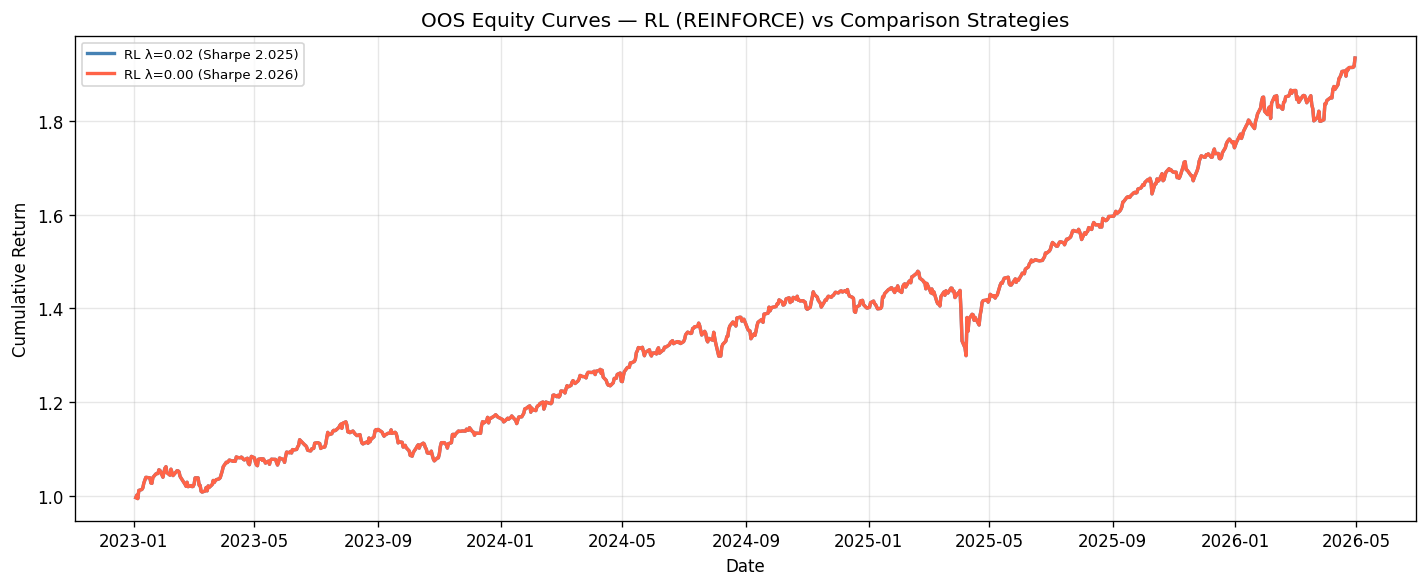

Saved equity_curves_rl.png


In [13]:
# --- Figure 1: equity_curves_rl.png ---
# OOS cumulative returns: RL configs + top-5 comparison strategies

# Load OOS returns for top-5 comparison strategies
# (from the 31-strategy parquet — use as gross proxy; net handled in CSV)
base_rets_path = ROOT / 'data' / 'cache' / 'portfolio_returns' / '31strategies_29assets_2003_2026.parquet'
try:
    base_rets = pd.read_parquet(base_rets_path)
    base_rets_oos = base_rets.loc[TEST_START:]
    top5_strats = full_df[~full_df.index.str.contains('RL_lambda')].head(5).index.tolist()
    available_strats = [s for s in top5_strats if s in base_rets_oos.columns]
    compare_rets = base_rets_oos[available_strats[:3]] if available_strats else pd.DataFrame()
except Exception:
    compare_rets = pd.DataFrame()

fig, ax = plt.subplots(figsize=(12, 5))

# RL curves
cum_A = (1 + ret_A).cumprod()
cum_B = (1 + ret_B).cumprod()
ax.plot(cum_A.index, cum_A.values, label=f'RL λ=0.02 (Sharpe {sharpe_A:.3f})', lw=2, color='steelblue')
ax.plot(cum_B.index, cum_B.values, label=f'RL λ=0.00 (Sharpe {sharpe_B:.3f})', lw=2, color='tomato')

# Comparison curves
colors = ['#888', '#aaa', '#bbb']
for i, col in enumerate(compare_rets.columns):
    cum = (1 + compare_rets[col]).cumprod()
    ax.plot(cum.index, cum.values, label=col, lw=1, alpha=0.7, color=colors[i % len(colors)])

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.set_title('OOS Equity Curves — RL (REINFORCE) vs Comparison Strategies')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'equity_curves_rl.png', dpi=150)
plt.show()
print(f'Saved equity_curves_rl.png')

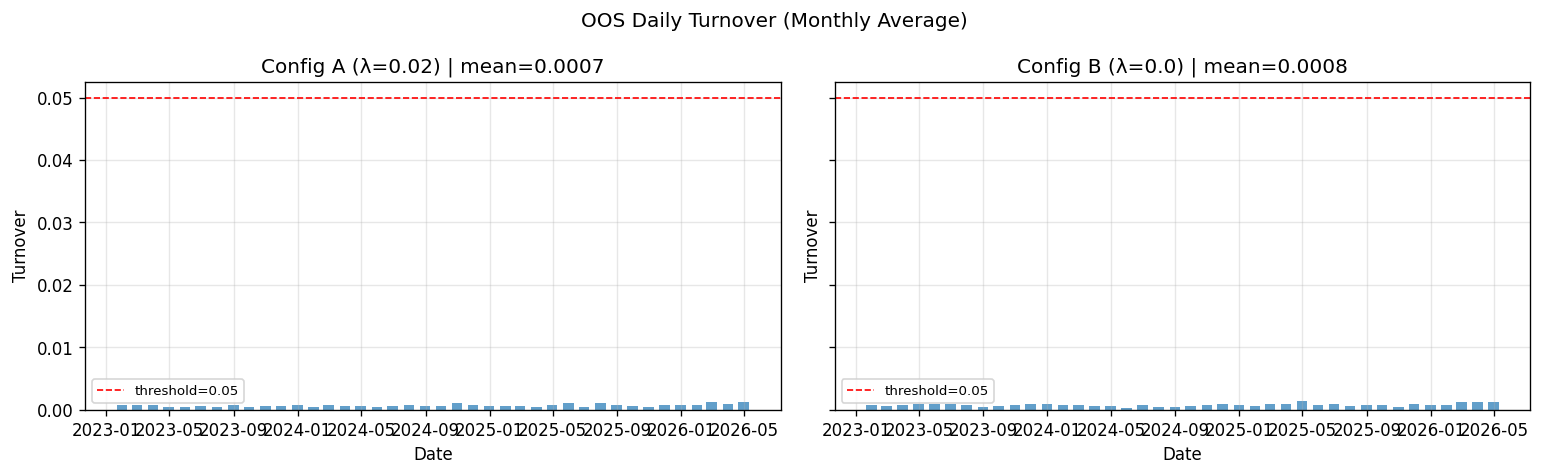

Saved turnover_over_time_rl.png


In [14]:
# --- Figure 2: turnover_over_time_rl.png ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, weights_df, config_name, lambda_val in [
    (axes[0], weights_A, 'Config A', LAMBDA_A),
    (axes[1], weights_B, 'Config B', LAMBDA_B),
]:
    # Daily turnover: sum of absolute weight changes
    to = weights_df.diff().abs().sum(axis=1).fillna(0)
    # Rebase to monthly for readability
    to_monthly = to.resample('ME').mean()
    ax.bar(to_monthly.index, to_monthly.values, width=20, alpha=0.7)
    ax.axhline(TO_THRESH, color='red', lw=1, ls='--', label=f'threshold={TO_THRESH}')
    ax.set_title(f'{config_name} (λ={lambda_val}) | mean={to.mean():.4f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Turnover')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('OOS Daily Turnover (Monthly Average)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'turnover_over_time_rl.png', dpi=150)
plt.show()
print('Saved turnover_over_time_rl.png')

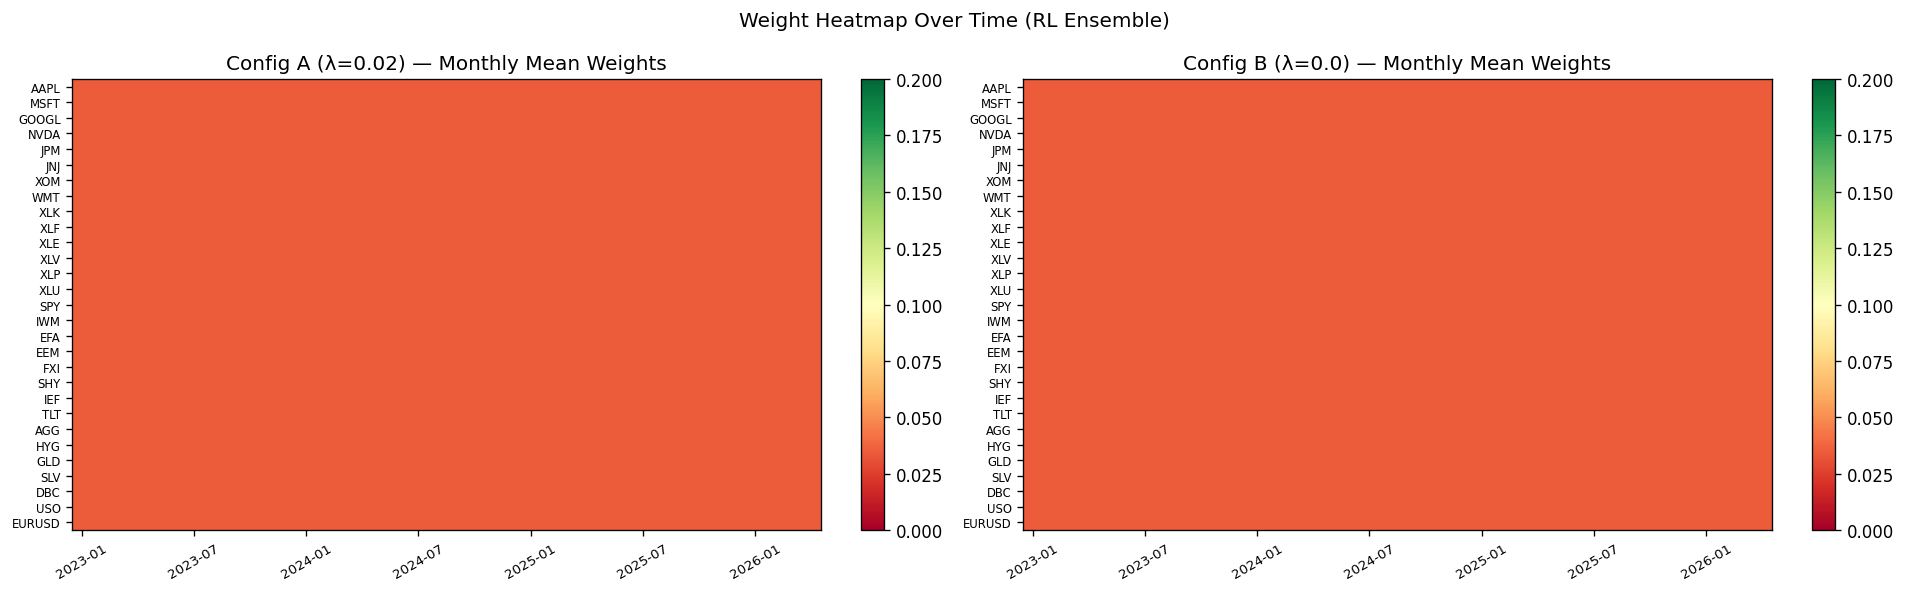

Saved weight_heatmap_rl.png


In [15]:
# --- Figure 3: weight_heatmap_rl.png ---

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, weights_df, config_name, lambda_val in [
    (axes[0], weights_A, 'Config A', LAMBDA_A),
    (axes[1], weights_B, 'Config B', LAMBDA_B),
]:
    # Resample to monthly mean for readability
    w_monthly = weights_df.resample('ME').mean()
    im = ax.imshow(
        w_monthly.T.values,
        aspect='auto',
        cmap='RdYlGn',
        vmin=0,
        vmax=0.2,
    )
    ax.set_yticks(range(N_ASSETS))
    ax.set_yticklabels([a.split('.')[0] for a in ASSETS], fontsize=7)
    ax.set_xticks(range(0, len(w_monthly), max(1, len(w_monthly)//6)))
    ax.set_xticklabels([d.strftime('%Y-%m') for d in w_monthly.index[::max(1, len(w_monthly)//6)]], rotation=30, fontsize=8)
    ax.set_title(f'{config_name} (λ={lambda_val}) — Monthly Mean Weights')
    plt.colorbar(im, ax=ax, fraction=0.03)

fig.suptitle('Weight Heatmap Over Time (RL Ensemble)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'weight_heatmap_rl.png', dpi=150)
plt.show()
print('Saved weight_heatmap_rl.png')

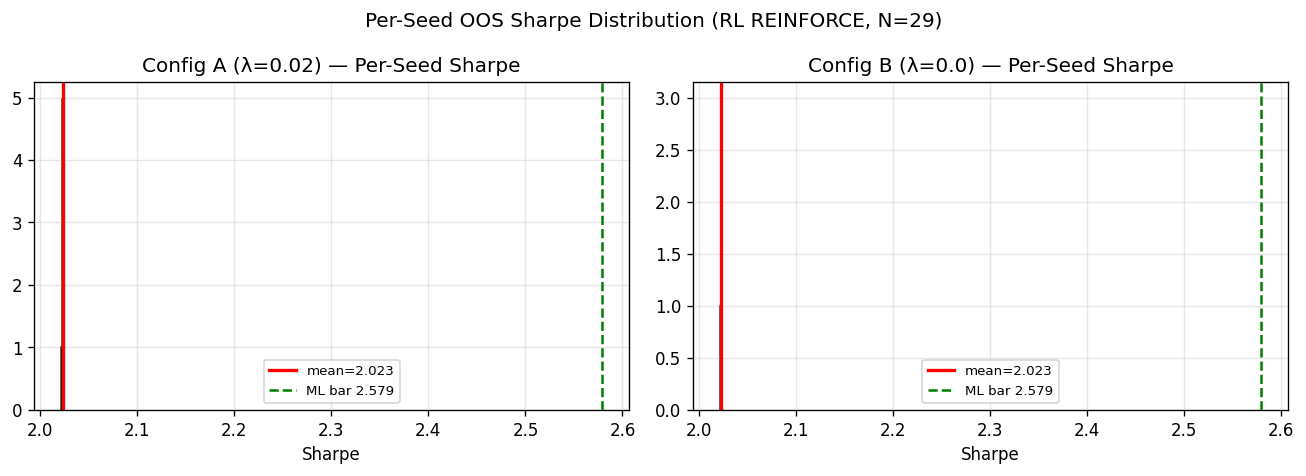

Saved seed_sharpe_dist_rl.png


In [16]:
# --- Figure 4: seed_sharpe_dist_rl.png ---

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, sharpe_list, config_name, lambda_val in [
    (axes[0], seed_sharpes_A, 'Config A', LAMBDA_A),
    (axes[1], seed_sharpes_B, 'Config B', LAMBDA_B),
]:
    ax.hist(sharpe_list, bins=max(3, len(sharpe_list)//2), edgecolor='k', alpha=0.7)
    ax.axvline(np.mean(sharpe_list), color='red', lw=2, label=f'mean={np.mean(sharpe_list):.3f}')
    ax.axvline(2.579, color='green', lw=1.5, ls='--', label='ML bar 2.579')
    ax.set_title(f'{config_name} (λ={lambda_val}) — Per-Seed Sharpe')
    ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Per-Seed OOS Sharpe Distribution (RL REINFORCE, N=29)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'seed_sharpe_dist_rl.png', dpi=150)
plt.show()
print('Saved seed_sharpe_dist_rl.png')

## §12 Summary

In [17]:
rl_rank_A = list(full_df.index).index('RL_lambda_002_ensemble') + 1
rl_rank_B = list(full_df.index).index('RL_lambda_000_ensemble') + 1

print('=' * 70)
print('SESSION 4c SUMMARY')
print('=' * 70)
print(f'Universe    : {N_ASSETS} assets, 2003-2026')
print(f'Methodology : REINFORCE+baseline, monthly walk-forward, {len(refit_dates)} refits')
print(f'Configs     : 2 (λ=0.02, λ=0.00)  |  Seeds: {len(SEEDS)}  |  Episodes: {EPISODES}')
print(f'Max steps   : {MAX_STEPS} ({"full rollout" if MAX_STEPS is None else "truncated"})')
print(f'Total fits  : {2 * len(SEEDS) * len(refit_dates)}')
print()
print(f'Config A (λ=0.02): Sharpe={sharpe_A:.4f}  Rank={rl_rank_A}/{len(full_df)}')
print(f'Config B (λ=0.00): Sharpe={sharpe_B:.4f}  Rank={rl_rank_B}/{len(full_df)}')
print(f'ML bar (reference): 2.579  (MSR Ensemble)')
print()
print(f'Static collapse verdict: {verdict}')
print()
print('Artifacts saved:')
print(f'  {out_csv}')
print(f'  {RESULTS_DIR}/diagnostics_all.parquet')
print(f'  {FIG_DIR}/*.png')
print()
print('Next: docs/handoff/session_4c_findings.md (fill in actual numbers)')

SESSION 4c SUMMARY
Universe    : 29 assets, 2003-2026
Methodology : REINFORCE+baseline, monthly walk-forward, 41 refits
Configs     : 2 (λ=0.02, λ=0.00)  |  Seeds: 10  |  Episodes: 200
Max steps   : None (full rollout)
Total fits  : 820

Config A (λ=0.02): Sharpe=2.0255  Rank=27/39
Config B (λ=0.00): Sharpe=2.0256  Rank=26/39
ML bar (reference): 2.579  (MSR Ensemble)

Static collapse verdict: STATIC_COLLAPSE_DETECTED

Artifacts saved:
  /content/next-gen-aiam/data/cache/portfolio_returns/full_comparison_with_rl.csv
  /content/next-gen-aiam/results/rl/n29/diagnostics_all.parquet
  /content/next-gen-aiam/results/rl/n29/figures/*.png

Next: docs/handoff/session_4c_findings.md (fill in actual numbers)


In [18]:
# Bundle artifacts for download
!cd /content/next-gen-aiam && zip -r /content/rl_n29_artifacts.zip \
    results/rl/n29/ docs/handoff/session_4c_findings.md

print("Ready to download: /content/rl_n29_artifacts.zip")
print("Open the file panel (folder icon, left sidebar) → find the zip → right-click → Download")

  adding: results/rl/n29/ (stored 0%)
  adding: results/rl/n29/figures/ (stored 0%)
  adding: results/rl/n29/figures/seed_sharpe_dist_rl.png (deflated 17%)
  adding: results/rl/n29/figures/turnover_over_time_rl.png (deflated 21%)
  adding: results/rl/n29/figures/weight_heatmap_rl.png (deflated 19%)
  adding: results/rl/n29/figures/equity_curves_rl.png (deflated 9%)
  adding: results/rl/n29/seed_sharpe_distribution.csv (deflated 48%)
  adding: results/rl/n29/diagnostics_all.parquet (deflated 28%)
  adding: docs/handoff/session_4c_findings.md (deflated 59%)
Ready to download: /content/rl_n29_artifacts.zip
Open the file panel (folder icon, left sidebar) → find the zip → right-click → Download


In [19]:
# HTML export with all outputs preserved
!jupyter nbconvert --to html \
    /content/next-gen-aiam/notebooks/04f_rl_n29_training.ipynb \
    --output /content/04f_rl_n29_training.html

print("HTML snapshot: /content/04f_rl_n29_training.html — download from file panel")

[NbConvertApp] Converting notebook /content/next-gen-aiam/notebooks/04f_rl_n29_training.ipynb to html
[NbConvertApp] Writing 398329 bytes to /content/04f_rl_n29_training.html
HTML snapshot: /content/04f_rl_n29_training.html — download from file panel
